# Notebook 04 — Hypothesis Testing (H1–H4)

All models use **logistic regression with session-clustered standard errors**,
consistent with the binary dependent variable (`extraction_2`) and the
replication model in Notebook 03.

Coefficients are on the **log-odds scale**; Average Marginal Effects (AME)
are computed for each hypothesis to aid interpretation.

| Hypothesis | Key coefficient | Expected sign |
|---|---|---|
| H1 | `liberal_z` | negative (liberals = lower score = greener) |
| H2 | `IT_present:liberal_z` | negative (IT stronger for liberals) |
| H3 | `IT_present:legacy_concern_comp_z` | positive (Prolific only) |
| H4 | `IT_present:env_concern_comp_z` | positive |

Controls in all models: `GI_present` (or condition dummies for H1),
`age`, `education`, `round`.

In [1]:
# ── Cell 1: Load clean data ──────────────────────────────────
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

df_mt = pd.read_csv('data/mturk_clean.csv')
df_pr = pd.read_csv('data/prolific_clean.csv')
datasets = {'mturk': df_mt, 'prolific': df_pr}
PLATFORMS = {'mturk': 'Study 1 (MTurk)', 'prolific': 'Study 2 (Prolific)'}

In [2]:
# ── Cell 2: Model-fitting helper ─────────────────────────────
# Shared function for all four hypothesis models.
# Uses logistic regression + session-clustered SEs.
# Returns the fitted model and prints the key interaction term.

def fit_hypothesis_model(df, formula, interaction_term,
                         label, hypothesis, expected_sign=None):

    # Identify moderator columns from the interaction term
    mod_cols = [t.strip() for t in interaction_term.split(':')]
    subset   = ['extraction_2', 'age', 'education', 'round', 'sessioncode']
    data = df.dropna(subset=subset + [c for c in mod_cols if c in df.columns])

    model = smf.logit(formula, data=data).fit(
        cov_type='cluster',
        cov_kwds={'groups': data['sessioncode']},
        disp=False
    )

    b   = model.params.get(interaction_term, np.nan)
    p   = model.pvalues.get(interaction_term, np.nan)
    se  = model.bse.get(interaction_term, np.nan)
    OR  = np.exp(b)
    sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'n.s.'

    if expected_sign is not None:
        supported = (
            (expected_sign == 'negative' and b < 0 and p < .05) or
            (expected_sign == 'positive' and b > 0 and p < .05)
        )
        verdict = '✓ SUPPORTED' if supported else '✗ NOT SUPPORTED'
    else:
        verdict = ''

    print(f"\n{'─'*60}")
    print(f"  {hypothesis}")
    print(f"  Platform: {label}")
    print(f"  N = {len(data):,}  |  Sessions = {data['sessioncode'].nunique()}")
    print(f"  β({interaction_term}) = {b:.4f}  SE={se:.4f}  "
          f"OR={OR:.3f}  p={p:.4f}  {sig}")
    print(f"  {verdict}")
    print(model.summary().tables[1])
    return model

In [3]:
# ── Cell 3: H1 — Ideology predicts green extraction ──────────
# Condition dummies included to isolate the ideology effect from
# treatment assignment (Proposal Section 3.5).
#
# Expected: β(liberal_z) < 0
#   Liberal = low score (1) → more likely to choose green.
#   Conservative = high score (7) → less likely to choose green.

FORMULA_H1 = (
    "extraction_2 ~ liberal_z + "
    "cond_IT_GI + cond_IT_only + cond_GI_only + "
    "age + education + round"
)

model_h1 = {}
for name, df in datasets.items():
    model_h1[name] = fit_hypothesis_model(
        df, FORMULA_H1, 'liberal_z',
        PLATFORMS[name],
        'H1: Liberals choose green more than conservatives',
        expected_sign='negative'
    )


────────────────────────────────────────────────────────────
  H1: Liberals choose green more than conservatives
  Platform: Study 1 (MTurk)
  N = 11,240  |  Sessions = 309
  β(liberal_z) = -0.0111  SE=0.0347  OR=0.989  p=0.7487  n.s.
  ✗ NOT SUPPORTED
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.5706      0.200     -7.861      0.000      -1.962      -1.179
liberal_z       -0.0111      0.035     -0.320      0.749      -0.079       0.057
cond_IT_GI       1.0221      0.124      8.218      0.000       0.778       1.266
cond_IT_only     0.6638      0.132      5.016      0.000       0.404       0.923
cond_GI_only     0.7658      0.126      6.085      0.000       0.519       1.012
age              0.0017      0.003      0.521      0.602      -0.005       0.008
education        0.0226      0.031      0.728      0.466      -0.038       0.083
round           -

In [4]:
# ── Cell 4: H2 — Ideology moderates the IT effect ────────────
# IT_present × liberal_z interaction.
# IT_present is the collapsed indicator (justified by Notebook 03 gate).
#
# Expected: β(IT_present:liberal_z) < 0
#   Negative interaction = IT effect is stronger (larger positive impact)
#   for lower values of liberal_z (i.e., for liberals).

FORMULA_H2 = (
    "extraction_2 ~ IT_present * liberal_z + "
    "GI_present + age + education + round"
)

model_h2 = {}
for name, df in datasets.items():
    model_h2[name] = fit_hypothesis_model(
        df, FORMULA_H2, 'IT_present:liberal_z',
        PLATFORMS[name],
        'H2: IT effect stronger for liberals',
        expected_sign='negative'
    )


────────────────────────────────────────────────────────────
  H2: IT effect stronger for liberals
  Platform: Study 1 (MTurk)
  N = 11,240  |  Sessions = 309
  β(IT_present:liberal_z) = 0.0150  SE=0.0697  OR=1.015  p=0.8293  n.s.
  ✗ NOT SUPPORTED
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -1.4513      0.198     -7.322      0.000      -1.840      -1.063
IT_present               0.4311      0.089      4.845      0.000       0.257       0.605
liberal_z               -0.0185      0.053     -0.347      0.728      -0.123       0.086
IT_present:liberal_z     0.0150      0.070      0.216      0.829      -0.122       0.152
GI_present               0.5447      0.090      6.054      0.000       0.368       0.721
age                      0.0021      0.003      0.674      0.500      -0.004       0.008
education                0.0193      0

In [5]:
# ── Cell 5: H3 — Legacy concern moderates the IT effect ──────
# Legacy concern items are in the Prolific survey only.
# MTurk is run if the column is present; otherwise skipped.
#
# Expected: β(IT_present:legacy_concern_comp_z) > 0
#   Positive interaction = IT effect is stronger for participants
#   who score higher on legacy concern (Wade-Benzoni & Tost, 2009).

FORMULA_H3 = (
    "extraction_2 ~ IT_present * legacy_concern_comp_z + "
    "GI_present + age + education + round"
)

model_h3 = {}

for name, df in datasets.items():
    if 'legacy_concern_comp_z' not in df.columns:
        print(f"{PLATFORMS[name]}: legacy_concern_comp_z absent — H3 skipped.")
        continue
    model_h3[name] = fit_hypothesis_model(
        df, FORMULA_H3, 'IT_present:legacy_concern_comp_z',
        PLATFORMS[name],
        'H3: Legacy concern moderates IT effect',
        expected_sign='positive'
    )

Study 1 (MTurk): legacy_concern_comp_z absent — H3 skipped.

────────────────────────────────────────────────────────────
  H3: Legacy concern moderates IT effect
  Platform: Study 2 (Prolific)
  N = 10,743  |  Sessions = 288
  β(IT_present:legacy_concern_comp_z) = -0.0630  SE=0.0770  OR=0.939  p=0.4130  n.s.
  ✗ NOT SUPPORTED
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -1.1735      0.159     -7.398      0.000      -1.484      -0.863
IT_present                           0.3431      0.098      3.513      0.000       0.152       0.535
legacy_concern_comp_z                0.0028      0.055      0.051      0.960      -0.106       0.111
IT_present:legacy_concern_comp_z    -0.0630      0.077     -0.819      0.413      -0.214       0.088
GI_present                           0.4184      0.099      4.240

In [6]:
# ── Cell 6: H4 — Environmental concern moderates the IT effect ─
# H4 is tested across four parallel sub-models (see 04b notebook).
# Rather than a single model_h4 dict, we build model_h4 as the
# PRIMARY sub-model (H4a: Milfont composite) so that downstream
# cells (AME tables, plots, summary) continue to work unchanged.
# The full four-way comparison lives in 04b_h4_environmental_submodels.ipynb.

FORMULA_H4a = (
    "extraction_2 ~ IT_present * env_concern_comp_z + "
    "GI_present + age + education + round"
)

# H4b / H4c / H4d formulas — run in parallel below
FORMULA_H4b = (
    "extraction_2 ~ IT_present * environment_worry_z + "
    "GI_present + age + education + round"
)
FORMULA_H4c = (
    "extraction_2 ~ IT_present * environment_responsib_z + "
    "GI_present + age + education + round"
)
FORMULA_H4d = (
    "extraction_2 ~ IT_present * environment_natural_p_z + "
    "GI_present + age + education + round"
)

# model_h4 = primary sub-model (H4a) — keeps downstream cells intact
model_h4  = {}   # H4a: Milfont composite (primary)
model_h4b = {}   # H4b: affective worry
model_h4c = {}   # H4c: personal responsibility
model_h4d = {}   # H4d: anthropogenic belief

for name, df in datasets.items():
    # H4a — primary
    if 'env_concern_comp_z' in df.columns:
        model_h4[name] = fit_hypothesis_model(
            df, FORMULA_H4a, 'IT_present:env_concern_comp_z',
            PLATFORMS[name],
            'H4a (primary): Milfont composite moderates IT effect',
            expected_sign='positive'
        )
    else:
        print(f"{PLATFORMS[name]}: env_concern_comp_z absent — H4a skipped.")

    # H4b — affective worry
    if 'environment_worry_z' in df.columns:
        model_h4b[name] = fit_hypothesis_model(
            df, FORMULA_H4b, 'IT_present:environment_worry_z',
            PLATFORMS[name],
            'H4b: Affective worry moderates IT effect',
            expected_sign='positive'
        )
    else:
        print(f"{PLATFORMS[name]}: environment_worry_z absent — H4b skipped.")

    # H4c — personal responsibility
    if 'environment_responsib_z' in df.columns:
        model_h4c[name] = fit_hypothesis_model(
            df, FORMULA_H4c, 'IT_present:environment_responsib_z',
            PLATFORMS[name],
            'H4c: Personal responsibility moderates IT effect',
            expected_sign='positive'
        )
    else:
        print(f"{PLATFORMS[name]}: environment_responsib_z absent — H4c skipped.")

    # H4d — anthropogenic belief
    if 'environment_natural_p_z' in df.columns:
        model_h4d[name] = fit_hypothesis_model(
            df, FORMULA_H4d, 'IT_present:environment_natural_p_z',
            PLATFORMS[name],
            'H4d: Anthropogenic belief moderates IT effect',
            expected_sign='positive'
        )
    else:
        print(f"{PLATFORMS[name]}: environment_natural_p_z absent — H4d skipped.")

Study 1 (MTurk): env_concern_comp_z absent — H4a skipped.

────────────────────────────────────────────────────────────
  H4b: Affective worry moderates IT effect
  Platform: Study 1 (MTurk)
  N = 11,240  |  Sessions = 309
  β(IT_present:environment_worry_z) = -0.0241  SE=0.0795  OR=0.976  p=0.7618  n.s.
  ✗ NOT SUPPORTED
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -1.4455      0.198     -7.315      0.000      -1.833      -1.058
IT_present                         0.4322      0.089      4.883      0.000       0.259       0.606
environment_worry_z                0.0773      0.057      1.365      0.172      -0.034       0.188
IT_present:environment_worry_z    -0.0241      0.080     -0.303      0.762      -0.180       0.132
GI_present                         0.5422      0.090      6.015      0.000       0

In [7]:
# ── Cell 7: Average Marginal Effects for interaction terms ────
# model_h4 (H4a primary) feeds into the shared AME table below.
# H4b/c/d AME tables are also printed for completeness.

def interaction_ame_table(df, model, treat_var, mod_var, platform_label):
    """
    Prints a 3-row table showing the treatment (IT) effect on
    Pr(green) at three levels of the moderator: -1 SD, Mean, +1 SD.
    Works for any logistic regression model fitted with smf.logit().
    """
    data = df.dropna(subset=[mod_var, treat_var])

    # Covariate means (everything except treat and moderator)
    cov_cols = [c for c in ['GI_present', 'age', 'education', 'round']
                if c in data.columns]
    means = {c: data[c].mean() for c in cov_cols}

    rows = []
    for level, lbl in [(-1.0, '-1 SD  (low)'),
                       ( 0.0, 'Mean'),
                       (+1.0, '+1 SD (high)')]:
        r0 = {treat_var: 0, mod_var: level, **means}
        r1 = {treat_var: 1, mod_var: level, **means}
        p0 = model.predict(pd.DataFrame([r0]))[0]
        p1 = model.predict(pd.DataFrame([r1]))[0]
        rows.append({
            'Moderator level':  lbl,
            'No IT  Pr(green)': round(p0, 4),
            'IT     Pr(green)': round(p1, 4),
            'Delta  Pr (IT)':   round(p1 - p0, 4),
        })

    tbl = pd.DataFrame(rows).set_index('Moderator level')
    print(f'  Platform : {platform_label}')
    print(f'  Moderator: {mod_var}')
    print(tbl.to_string())
    print()


# ── H2 ──────────────────────────────────────────────────────
print('\n=== H2: IT x Ideology ===')
for name, m in model_h2.items():
    interaction_ame_table(datasets[name], m, 'IT_present',
                          'liberal_z', PLATFORMS[name])

# ── H3 ──────────────────────────────────────────────────────
print('\n=== H3: IT x Legacy Concern ===')
for name, m in model_h3.items():
    interaction_ame_table(datasets[name], m, 'IT_present',
                          'legacy_concern_comp_z', PLATFORMS[name])

# ── H4a: Milfont composite ──────────────────────────────────
print('\n=== H4a: IT x Env. Concern Composite (Milfont) ===')
for name, m in model_h4.items():
    interaction_ame_table(datasets[name], m, 'IT_present',
                          'env_concern_comp_z', PLATFORMS[name])

# ── H4b: Affective worry ────────────────────────────────────
print('\n=== H4b: IT x Affective Worry ===')
for name, m in model_h4b.items():
    interaction_ame_table(datasets[name], m, 'IT_present',
                          'environment_worry_z', PLATFORMS[name])

# ── H4c: Personal responsibility ────────────────────────────
print('\n=== H4c: IT x Personal Responsibility ===')
for name, m in model_h4c.items():
    interaction_ame_table(datasets[name], m, 'IT_present',
                          'environment_responsib_z', PLATFORMS[name])

# ── H4d: Anthropogenic belief ───────────────────────────────
print('\n=== H4d: IT x Anthropogenic Belief ===')
for name, m in model_h4d.items():
    interaction_ame_table(datasets[name], m, 'IT_present',
                          'environment_natural_p_z', PLATFORMS[name])



=== H2: IT x Ideology ===
  Platform : Study 1 (MTurk)
  Moderator: liberal_z
                 No IT  Pr(green)  IT     Pr(green)  Delta  Pr (IT)
Moderator level                                                    
-1 SD  (low)               0.2250            0.3057          0.0806
Mean                       0.2218            0.3049          0.0831
+1 SD (high)               0.2186            0.3042          0.0855

  Platform : Study 2 (Prolific)
  Moderator: liberal_z
                 No IT  Pr(green)  IT     Pr(green)  Delta  Pr (IT)
Moderator level                                                    
-1 SD  (low)               0.2905            0.3598          0.0693
Mean                       0.2679            0.3404          0.0724
+1 SD (high)               0.2465            0.3214          0.0749


=== H3: IT x Legacy Concern ===
  Platform : Study 2 (Prolific)
  Moderator: legacy_concern_comp_z
                 No IT  Pr(green)  IT     Pr(green)  Delta  Pr (IT)
Moderator level 

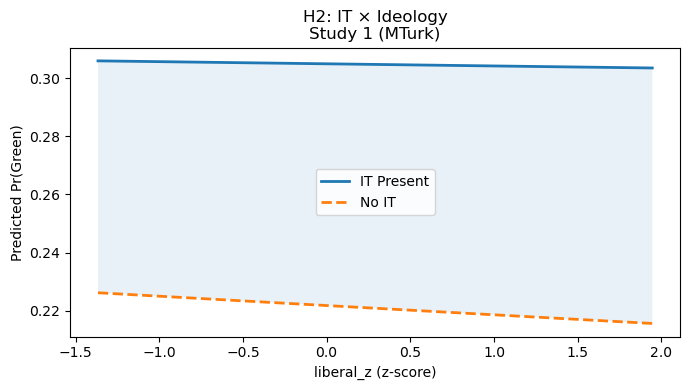

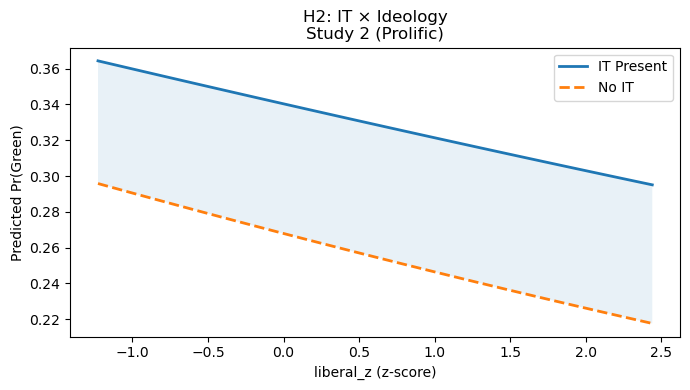

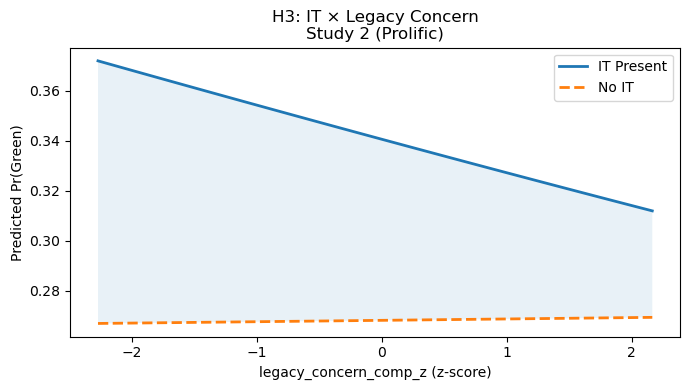

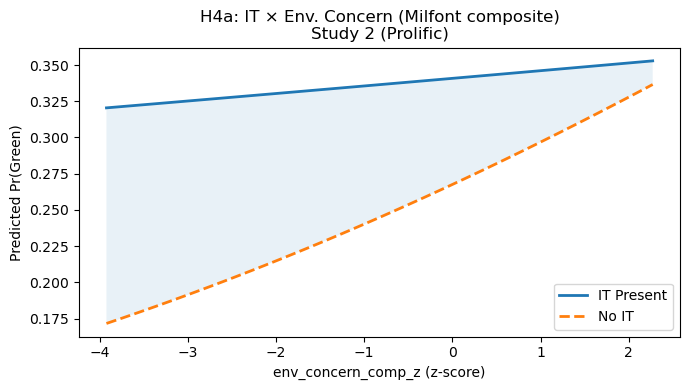

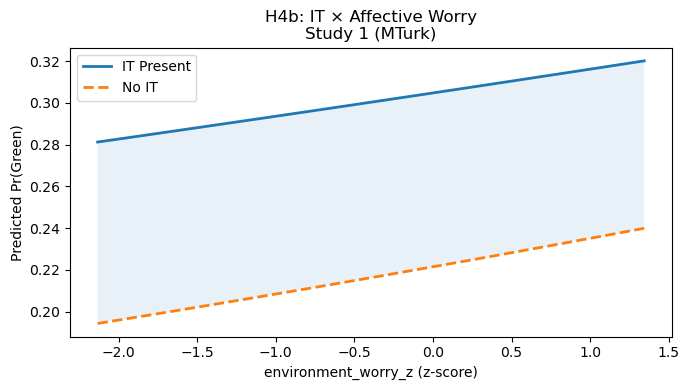

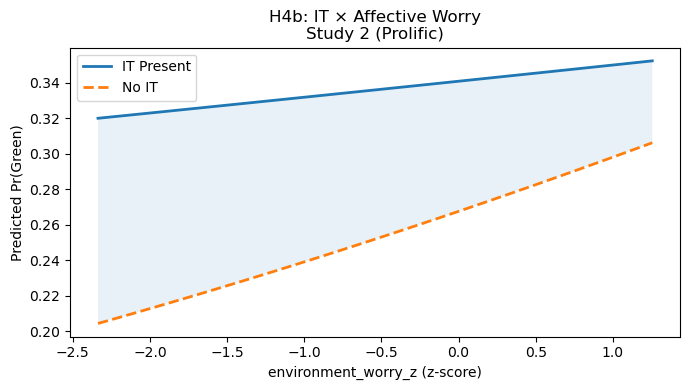

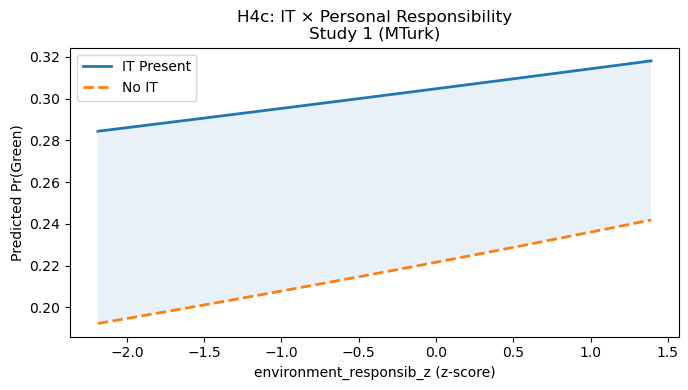

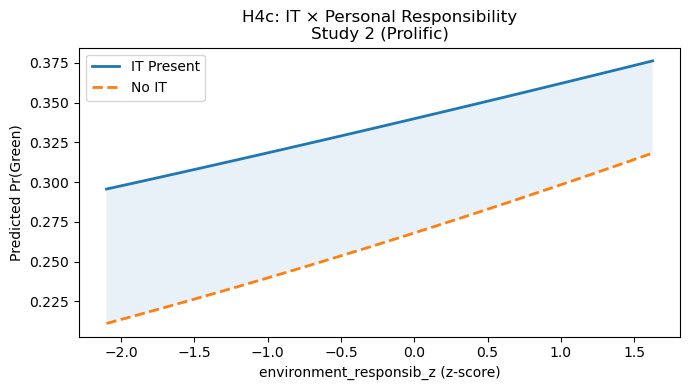

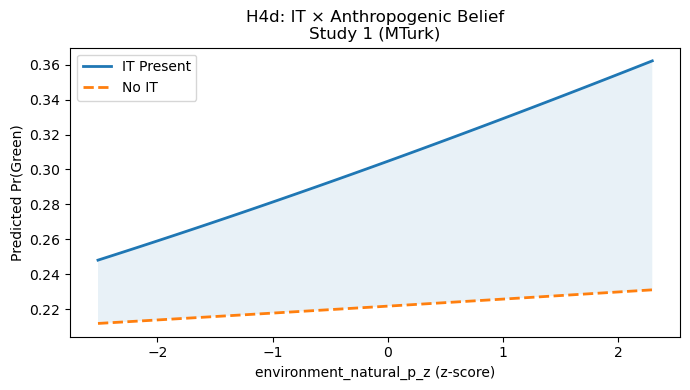

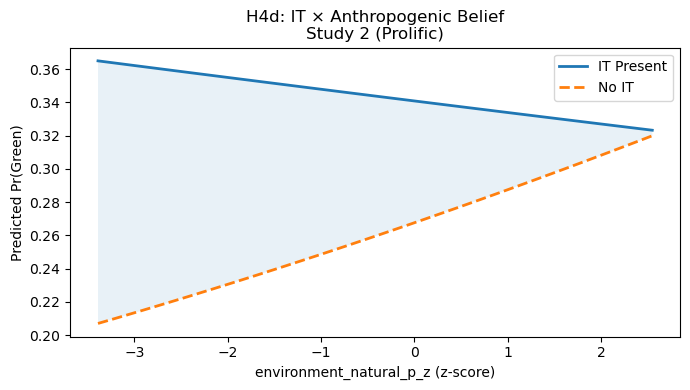

In [8]:
# ── Cell 8: Marginal effects plots ───────────────────────────
# H1, H2, H3 unchanged.
# H4: plots for all four sub-models (H4a–H4d).

def plot_margins(df, model, mod_var, platform_label, title, fname):
    data   = df.dropna(subset=[mod_var])
    cov_cols = [c for c in ['GI_present','age','education','round'] if c in data.columns]
    means  = {c: data[c].mean() for c in cov_cols}
    rng    = np.linspace(data[mod_var].min(), data[mod_var].max(), 100)
    p0 = [model.predict(pd.DataFrame([{'IT_present':0, mod_var:v, **means}]))[0] for v in rng]
    p1 = [model.predict(pd.DataFrame([{'IT_present':1, mod_var:v, **means}]))[0] for v in rng]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(rng, p1, label='IT Present', lw=2)
    ax.plot(rng, p0, label='No IT', lw=2, linestyle='--')
    ax.fill_between(rng, p0, p1, alpha=0.1)
    ax.set_xlabel(f'{mod_var} (z-score)'); ax.set_ylabel('Predicted Pr(Green)')
    ax.set_title(f'{title}\n{platform_label}'); ax.legend()
    plt.tight_layout()
    plt.savefig(f'outputs/{fname}', bbox_inches='tight'); plt.show()

for name, m in model_h2.items():
    plot_margins(datasets[name], m, 'liberal_z', PLATFORMS[name],
                 'H2: IT × Ideology', f'fig_h2_margins_{name}.png')

for name, m in model_h3.items():
    plot_margins(datasets[name], m, 'legacy_concern_comp_z',
                 PLATFORMS[name], 'H3: IT × Legacy Concern',
                 f'fig_h3_margins_{name}.png')

# H4 sub-models
H4_PLOT_CONFIG = [
    (model_h4,  'env_concern_comp_z',
     'H4a: IT × Env. Concern (Milfont composite)',  'fig_h4a_margins'),
    (model_h4b, 'environment_worry_z',
     'H4b: IT × Affective Worry',                  'fig_h4b_margins'),
    (model_h4c, 'environment_responsib_z',
     'H4c: IT × Personal Responsibility',          'fig_h4c_margins'),
    (model_h4d, 'environment_natural_p_z',
     'H4d: IT × Anthropogenic Belief',             'fig_h4d_margins'),
]

for mdict, mod_z, title, fname_base in H4_PLOT_CONFIG:
    for name, m in mdict.items():
        if mod_z in datasets[name].columns:
            plot_margins(datasets[name], m, mod_z, PLATFORMS[name],
                         title, f'{fname_base}_{name}.png')

In [11]:
# ── Cell 9: Hypothesis summary table ─────────────────────────
# H4 section now covers all four sub-models (H4a–H4d).

rows = []
entries = [
    ('H1',  'liberal_z',                          'negative', model_h1),
    ('H2',  'IT_present:liberal_z',               'negative', model_h2),
    ('H3',  'IT_present:legacy_concern_comp_z',   'positive', model_h3),
    # H4 sub-models — each is a separate entry
    ('H4a', 'IT_present:env_concern_comp_z',      'positive', model_h4),
    ('H4b', 'IT_present:environment_worry_z',     'positive', model_h4b),
    ('H4c', 'IT_present:environment_responsib_z', 'positive', model_h4c),
    ('H4d', 'IT_present:environment_natural_p_z', 'positive', model_h4d),
]

for hyp, term, expected, mdict in entries:
    for name, m in mdict.items():
        b   = m.params.get(term, np.nan)
        p   = m.pvalues.get(term, np.nan)
        se  = m.bse.get(term, np.nan)
        OR  = round(np.exp(b), 3) if not np.isnan(b) else np.nan
        sig = ('***' if p<.001 else '**' if p<.01
               else '*'  if p<.05 else 'n.s.')
        supported = (
            (expected == 'negative' and b < 0 and p < .05) or
            (expected == 'positive' and b > 0 and p < .05)
        )
        rows.append({
            'Hypothesis':  hyp,
            'Platform':    PLATFORMS[name],
            'Coefficient': term,
            'log-odds β':  round(b, 4),
            'OR':          OR,
            'SE':          round(se, 4),
            'p':           round(p, 4),
            'Sig':         sig,
            'Supported':   '✓' if supported else '✗'
        })

summary = pd.DataFrame(rows)
print("=== Hypothesis Summary ===")
print(summary.to_string(index=False))
summary.to_csv('outputs/hypothesis_summary.csv', index=False)
print("Saved: outputs/hypothesis_summary.csv")

=== Hypothesis Summary ===
Hypothesis           Platform                        Coefficient  log-odds β    OR     SE      p  Sig Supported
        H1    Study 1 (MTurk)                          liberal_z     -0.0111 0.989 0.0347 0.7487 n.s.         ✗
        H1 Study 2 (Prolific)                          liberal_z     -0.0980 0.907 0.0386 0.0111    *         ✓
        H2    Study 1 (MTurk)               IT_present:liberal_z      0.0150 1.015 0.0697 0.8293 n.s.         ✗
        H2 Study 2 (Prolific)               IT_present:liberal_z      0.0267 1.027 0.0765 0.7276 n.s.         ✗
        H3 Study 2 (Prolific)   IT_present:legacy_concern_comp_z     -0.0630 0.939 0.0770 0.4130 n.s.         ✗
       H4a Study 2 (Prolific)      IT_present:env_concern_comp_z     -0.1210 0.886 0.0728 0.0966 n.s.         ✗
       H4b    Study 1 (MTurk)     IT_present:environment_worry_z     -0.0241 0.976 0.0795 0.7618 n.s.         ✗
       H4b Study 2 (Prolific)     IT_present:environment_worry_z     -0.1102 